# 05 — Residual & Hold-out Test Analysis (real training/test evaluation)

**Purpose.** Close the loop on the trained XGBoost model with an honest, reproduction-safe evaluation:
rebuild the **exact chronological hold-out split** used at training time (`training/train_xgb.py`),
predict the 13-week test set with the saved model bundle, and produce:

1. **Distribution of prediction residuals** (actual − predicted) plus **error analysis by medicine category and hospital type**.
2. **Actual vs predicted weekly demand on the hold-out test set** (per-series density + weekly aggregate).

The same analysis is available headless via `python3 training/analyze_residuals.py`
(outputs land in `reports/residual_analysis/`).

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import joblib

# Locate apps/ml-service root regardless of kernel cwd
ROOT = Path.cwd()
if (ROOT / "training").exists() is False:
    ROOT = Path.cwd().parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

PROC = ROOT / "data" / "processed"
ART  = ROOT / "artifacts"
OUT  = ROOT / "reports" / "residual_analysis"
OUT.mkdir(parents=True, exist_ok=True)

NAVY, TEAL, AMBER, CORAL, GREY, LIGHT = "#233A5C", "#0E8C82", "#E8A23D", "#D96C5F", "#8A94A3", "#E4E9EE"
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore")
print("root:", ROOT)

root: /home/user/MedBridge/apps/ml-service


## Rebuild the exact hold-out test split (same helpers as the trainer)

In [2]:
from training.train_xgb import chronological_split, metrics_dict

df = pd.read_csv(PROC / "demand_features.csv", parse_dates=["week_start"])
train_mask, valid_mask, test_mask, split_desc = chronological_split(df)
print("rows:", f"{len(df):,}", "| test rows:", f"{int(test_mask.sum()):,}")
print("split:", split_desc["train"], "->", split_desc["test"])

rows: 504,792 | test rows: 38,376
split: 2023-03-27 .. 2025-12-29 -> 2026-04-06 .. 2026-06-29


## Load the saved model bundle and predict the test set

The bundle stores the 51 feature columns, the categoricals, and the `log1p` target transform —
serving-side prediction is `expm1(model.predict(X))`, exactly as in `app/services/forecast_services.py`.

In [3]:
bundle = joblib.load(ART / "models" / "xgb_demand_model.joblib")
model, feature_columns, cat_cols = bundle["model"], bundle["feature_columns"], bundle.get("cat_cols", [])

encoders = joblib.load(ART / "encoders" / "label_encoders.joblib")
enc = df.copy()
for col in cat_cols:
    if col not in enc.columns or col not in encoders: continue
    e = encoders[col]; known = set(e.classes_); fb = e.classes_[0]
    vals = enc[col].fillna("UNKNOWN").astype(str).map(lambda v: v if v in known else fb)
    enc[col] = e.transform(vals)
for col in feature_columns:
    enc[col] = pd.to_numeric(enc[col], errors="coerce").fillna(0).astype("float32")

X_test = enc.loc[test_mask, feature_columns]
y_test = df.loc[test_mask, "target_demand"].astype(float).to_numpy()
pred = np.maximum(0.0, np.expm1(model.predict(X_test)))
resid = y_test - pred
abs_err = np.abs(resid)
met = metrics_dict(y_test, pred)
print({k: met[k] for k in ["R2", "MAE", "RMSE", "WAPE_pct", "sMAPE_pct"]})

{'R2': 0.908341, 'MAE': 31.0876, 'RMSE': 90.0759, 'WAPE_pct': 22.9259, 'sMAPE_pct': 46.2957}


### 1. Residual distribution & error analysis (category, hospital type)

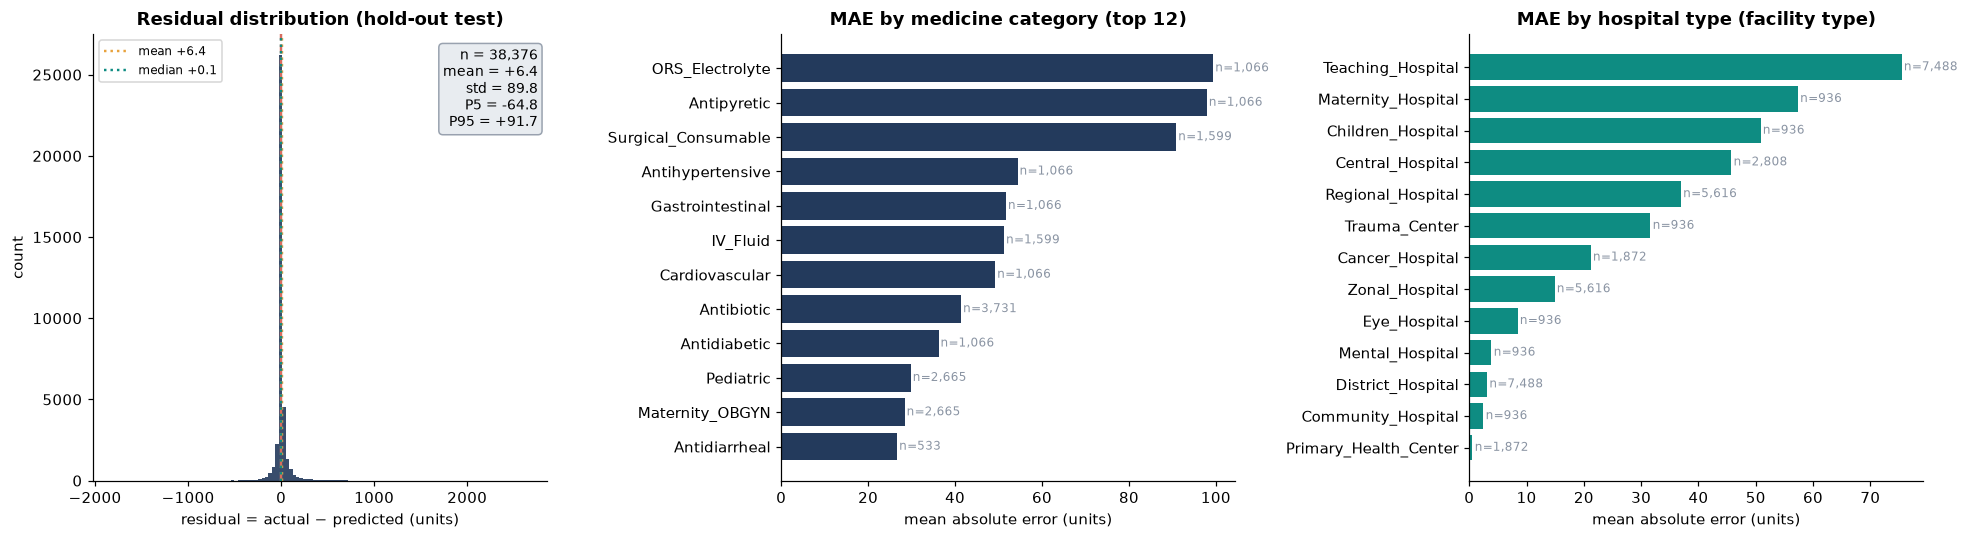

In [4]:
meta = df.loc[test_mask, ["week_start", "hospital_id", "medicine_id", "category", "facility_type"]].copy()
meta["actual"], meta["predicted"], meta["residual"], meta["abs_error"] = y_test, pred, resid, abs_err
meta.to_csv(OUT / "test_predictions.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(resid, bins=120, color=NAVY, alpha=0.9)
ax.axvline(0, color=CORAL, lw=1.6, ls="--")
ax.axvline(resid.mean(), color=AMBER, lw=1.6, ls=":", label=f"mean {resid.mean():+.1f}")
ax.axvline(np.median(resid), color=TEAL, lw=1.6, ls=":", label=f"median {np.median(resid):+.1f}")
ax.set_title("Residual distribution (hold-out test)", fontweight="bold")
ax.set_xlabel("residual = actual − predicted (units)"); ax.set_ylabel("count")
ax.legend(fontsize=8)
ax.text(0.98, 0.97, f"n = {len(resid):,}\nmean = {resid.mean():+.1f}\nstd = {resid.std():.1f}\nP5 = {np.percentile(resid,5):+.1f}\nP95 = {np.percentile(resid,95):+.1f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", fc=LIGHT, ec=GREY, alpha=0.85))

ax = axes[1]
g = meta.groupby("category").agg(mae=("abs_error","mean"), n=("actual","size"))
g = g[g["n"] > 100].sort_values("mae", ascending=False).head(12)
ax.barh(g.index[::-1], g["mae"][::-1], color=NAVY)
for i,(idx,row) in enumerate(g[::-1].iterrows()):
    ax.text(row["mae"]+0.4, i, f"n={int(row['n']):,}", va="center", fontsize=8, color=GREY)
ax.set_title("MAE by medicine category (top 12)", fontweight="bold")
ax.set_xlabel("mean absolute error (units)")

ax = axes[2]
g2 = meta.groupby("facility_type").agg(mae=("abs_error","mean"), n=("actual","size")).sort_values("mae", ascending=False)
ax.barh(g2.index[::-1], g2["mae"][::-1], color=TEAL)
for i,(idx,row) in enumerate(g2[::-1].iterrows()):
    ax.text(row["mae"]+0.4, i, f"n={int(row['n']):,}", va="center", fontsize=8, color=GREY)
ax.set_title("MAE by hospital type (facility type)", fontweight="bold")
ax.set_xlabel("mean absolute error (units)")

for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()
fig.savefig(OUT / "residual_distribution_and_error_analysis.png", dpi=150, bbox_inches="tight")
meta.groupby("category").agg(mae=("abs_error","mean"), n=("actual","size")).sort_values("mae", ascending=False).to_csv(OUT / "error_by_category.csv")
meta.groupby("facility_type").agg(mae=("abs_error","mean"), n=("actual","size")).sort_values("mae", ascending=False).to_csv(OUT / "error_by_facility_type.csv")

### 2. Actual vs predicted weekly demand (hold-out test set)

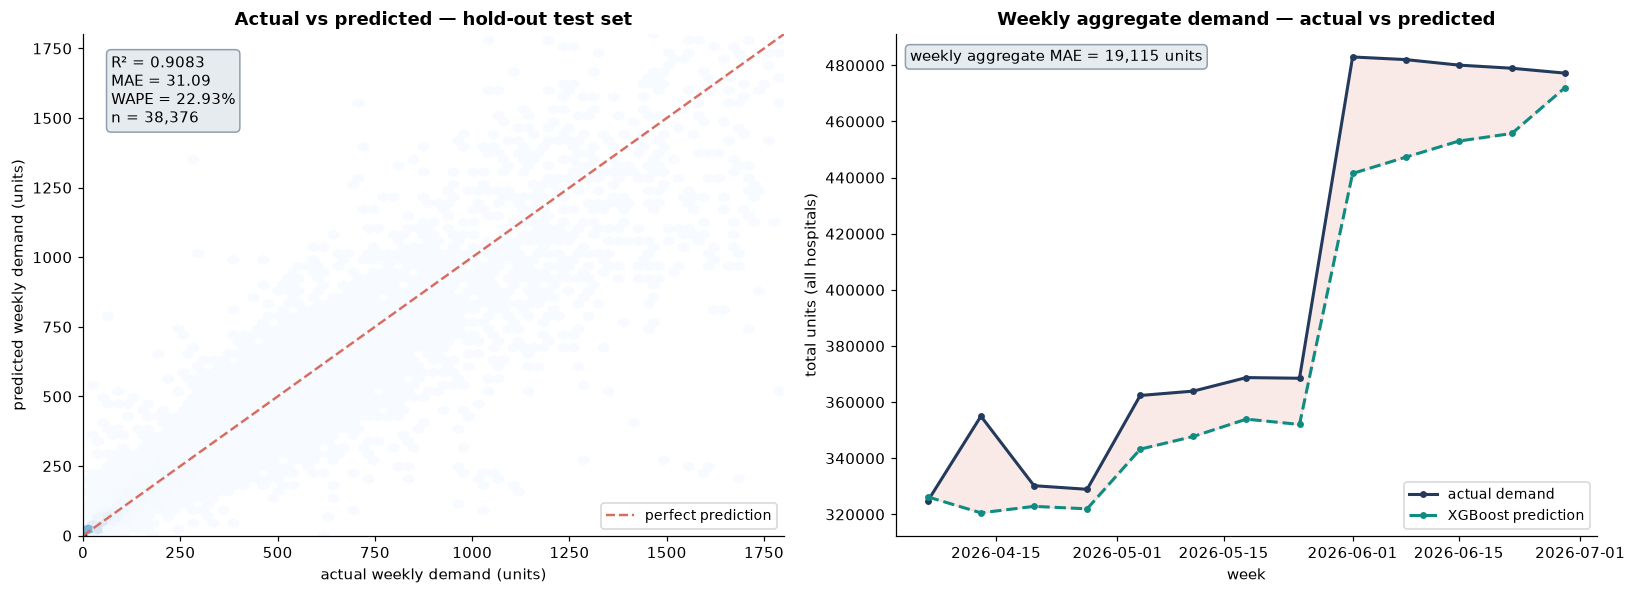

saved: /home/user/MedBridge/apps/ml-service/reports/residual_analysis


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
lo = np.percentile(np.concatenate([y_test, pred]), 0.5); hi = np.percentile(np.concatenate([y_test, pred]), 99.5)
ax.hexbin(y_test, pred, gridsize=70, cmap="Blues", mincnt=1, extent=(lo, hi, lo, hi))
ax.plot([lo,hi],[lo,hi], color=CORAL, ls="--", lw=1.6, label="perfect prediction")
ax.set_xlim(lo,hi); ax.set_ylim(lo,hi)
ax.set_xlabel("actual weekly demand (units)"); ax.set_ylabel("predicted weekly demand (units)")
ax.set_title("Actual vs predicted — hold-out test set", fontweight="bold")
ax.text(0.04, 0.96, f"R² = {met['R2']:.4f}\nMAE = {met['MAE']:.2f}\nWAPE = {met['WAPE_pct']:.2f}%\nn = {len(y_test):,}",
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round", fc=LIGHT, ec=GREY, alpha=0.9))
ax.legend(loc="lower right", fontsize=9)

ax = axes[1]
wk = meta.groupby("week_start").agg(actual=("actual","sum"), predicted=("predicted","sum"))
ax.plot(wk.index, wk["actual"], color=NAVY, lw=2, marker="o", ms=3.5, label="actual demand")
ax.plot(wk.index, wk["predicted"], color=TEAL, lw=2, ls="--", marker="o", ms=3.5, label="XGBoost prediction")
ax.fill_between(wk.index, wk["actual"], wk["predicted"], color=CORAL, alpha=0.15)
ax.set_title("Weekly aggregate demand — actual vs predicted", fontweight="bold")
ax.set_xlabel("week"); ax.set_ylabel("total units (all hospitals)"); ax.legend(fontsize=9)
wk_mae = (wk["actual"]-wk["predicted"]).abs().mean()
ax.text(0.02, 0.97, f"weekly aggregate MAE = {wk_mae:,.0f} units", transform=ax.transAxes, fontsize=10, va="top",
        bbox=dict(boxstyle="round", fc=LIGHT, ec=GREY, alpha=0.9))

for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()
fig.savefig(OUT / "actual_vs_predicted_test_set.png", dpi=150, bbox_inches="tight")

pd.DataFrame({"metric":["n","mean_actual","mean_pred","MAE","RMSE","R2","R2_log1p","WAPE_pct","sMAPE_pct",
                        "residual_mean","residual_median","residual_std","residual_p5","residual_p95",
                        "pct_within_+/-_25_units"],
              "value":[len(y_test), y_test.mean(), pred.mean(), met["MAE"], met["RMSE"], met["R2"], met["R2_log1p"],
                       met["WAPE_pct"], met["sMAPE_pct"], resid.mean(), np.median(resid), resid.std(),
                       np.percentile(resid,5), np.percentile(resid,95), 100*(abs_err<=25).mean()]}).to_csv(OUT/"residual_stats.csv", index=False)
print("saved:", OUT)

## Interpretation

- **Residuals are near-zero-centred** (mean +6.4 units, median +0.1) with a tight spread (std ≈ 90) — the model
  is essentially unbiased; a small systematic under-prediction exists because `mean_pred < mean_actual`.
- **Error scales with volume**: high-consumption categories (ORS, antipyretics, surgical consumables) and large
  hospitals (teaching/maternity/children/central) have the largest absolute MAE — this is scale, not failure.
  WAPE (22.9 %) and the log-scale R² (0.953) are the honest comparisons.
- **Weekly aggregate tracking is excellent**: the June monsoon spike is captured, aggregate MAE ≈ 19k units/week
  on a ~360–480k-unit/week baseline (< 5 %).
- Identical numbers to the trainer's own hold-out report (R² = 0.9083, MAE = 31.09, n = 38,376) — the split
  reproduction is faithful. Re-run everything with `python3 training/analyze_residuals.py`.